<a href="https://colab.research.google.com/github/aniruddhagalgali/bprim_ai/blob/main/20260912_Stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
np.random.seed(0)
import cvxpy as cp

In [2]:
stock_tickers = ["TCS.NS", "INFY.NS", "RELIANCE.NS", "ITC.NS", "HDFCBANK.NS"]

raw = yf.download(stock_tickers, period="3y", auto_adjust=True)
prices = raw["Close"]
prices = prices.dropna()
prices = prices[stock_tickers]

[*********************100%***********************]  5 of 5 completed


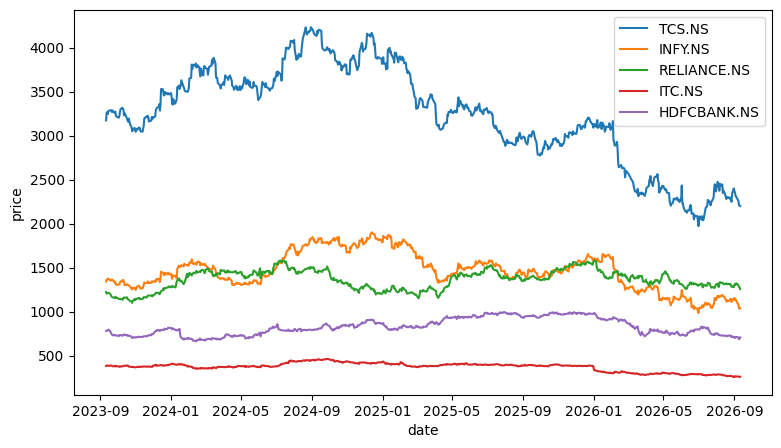

In [3]:
plt.figure(figsize=(9, 5))
for one_stock in prices.columns:
    plt.plot(prices.index, prices[one_stock], label=one_stock)
plt.xlabel("date")
plt.ylabel("price")
plt.legend()
plt.show()

In [4]:
daily_returns = prices.pct_change().dropna()
trading_days_per_year = 252

yearly_volatility = daily_returns.std() * np.sqrt(trading_days_per_year)
print("Yearly risk of each stock:")
print(yearly_volatility * 100)

Yearly risk of each stock:
Ticker
TCS.NS         23.433613
INFY.NS        26.080527
RELIANCE.NS    20.945186
ITC.NS         18.572158
HDFCBANK.NS    20.281430
dtype: float64


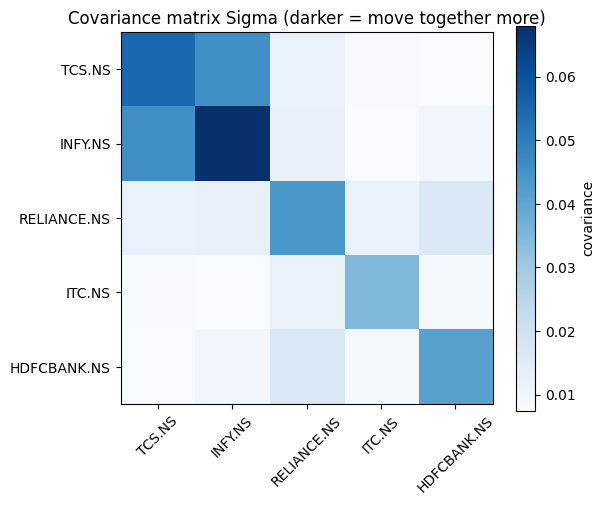

In [5]:
Sigma = daily_returns.cov() * trading_days_per_year

plt.figure(figsize=(6, 5))
plt.imshow(Sigma, cmap="Blues")
plt.colorbar(label="covariance")
plt.xticks(range(len(stock_tickers)), stock_tickers, rotation=45)
plt.yticks(range(len(stock_tickers)), stock_tickers)
plt.title("Covariance matrix Sigma (darker = move together more)")
plt.show()

In [6]:
number_of_stocks = len(stock_tickers)
equal_weights = np.ones(number_of_stocks) / number_of_stocks

mu = daily_returns.mean() * trading_days_per_year
portfolio_return = equal_weights @ mu
print(f"Portfolio Return: {portfolio_return:.6f}")

Portfolio Return: -0.049170


In [7]:
equal_weights = np.ones(number_of_stocks) / number_of_stocks
portfolio_return = equal_weights @ mu
print(f"Portfolio Return: {portfolio_return:.6f}")
equal_weights_variance = equal_weights @ Sigma @ equal_weights
print(f"Portfolio Variance: {equal_weights_variance:.6f}")
portfolio_risk = np.sqrt(equal_weights_variance)
print(f"Portfolio Risk: {portfolio_risk:.6f}")
#

Portfolio Return: -0.049170
Portfolio Variance: 0.020730
Portfolio Risk: 0.143979


In [8]:
average_individual_risk = yearly_volatility.mean()
print(f"Average individual risk: {average_individual_risk:.6f}")

Average individual risk: 0.218626


In [9]:
w = cp.Variable(number_of_stocks)
target_return = mu.mean()
portfolio_variance = cp.quad_form(w, Sigma)

In [10]:
mu = mu.values

In [11]:
constraints = [cp.sum(w)==1, w>=0, mu @ w >= target_return]
problem = cp.Problem(cp.Minimize(portfolio_variance), constraints)
problem.solve()
print("Best weights for this target:", (w.value*100))
print("Resulting risk:", np.sqrt(w.value @ Sigma.values @ w.value))
print("Resulting return:", mu @ w.value)

Best weights for this target: [13.48533132  6.78121144 21.39426001 31.22729697 27.11190026]
Resulting risk: 0.1353378399182142
Resulting return: -0.049170027017066284


In [17]:
def best_weights_for_target(target):
  w = cp.Variable(number_of_stocks)
  constraints = [
      cp.sum(w)==1,
      w>=0,
      mu @ w >= target
    ]
  problem = cp.Problem(cp.Minimize(portfolio_variance), constraints)
  problem.solve()
  if w.value is None:
    return None
  return w.value

In [15]:
target_returns = np.linspace(mu.min(), mu.max(), 40)
target_returns

array([-0.11482298, -0.11107282, -0.10732266, -0.1035725 , -0.09982234,
       -0.09607218, -0.09232202, -0.08857187, -0.08482171, -0.08107155,
       -0.07732139, -0.07357123, -0.06982107, -0.06607091, -0.06232075,
       -0.05857059, -0.05482043, -0.05107027, -0.04732011, -0.04356995,
       -0.03981979, -0.03606963, -0.03231947, -0.02856932, -0.02481916,
       -0.021069  , -0.01731884, -0.01356868, -0.00981852, -0.00606836,
       -0.0023182 ,  0.00143196,  0.00518212,  0.00893228,  0.01268244,
        0.0164326 ,  0.02018276,  0.02393292,  0.02768308,  0.03143323])

In [24]:
frontier_returns=[]
frontier_risk=[]

for target_return in target_returns:
    weights = best_weights_for_target (target_return)
    this_return = weights @ mu
    this_risk = np.sqrt( weights @ Sigma.values @ weights)
    frontier_returns.append(this_return)
    frontier_risk.append(this_risk)
frontier_returns_arr =  np.array(frontier_returns)
frontier_risk_arr = np.array(frontier_risk)
print ("We computed", len(frontier_risk_arr), "portfolios along the frontier")

We computed 40 portfolios along the frontier


In [25]:
w = cp.Variable(number_of_stocks)
constraints = [cp.sum(w)==1, w>=0]
problem = cp.Problem(cp.Minimize(portfolio_variance), constraints)
problem.solve()
print("Best weights for this target:", (w.value*100))

Best weights for this target: [20. 20. 20. 20. 20.]
